In [1]:
import os
import re
import numpy as np
import yaml
import matplotlib.pyplot as plt
from scipy.signal import iirfilter, sosfiltfilt

# Configuration
# Directory where the *_normalized.npy files live (post-ITI subtraction & scaling)
normalized_data_path = r"D:\Per Patient Normalization Output without the first 3 trials"

# Directory to save final filtered/downsampled data
filtered_data_path = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ theta range"
os.makedirs(filtered_data_path, exist_ok=True)

# Filter parameters for theta waves (typically 4-7 Hz)
low_freq = 4    # Hz, lower bound for theta waves
high_freq = 7   # Hz, upper bound for theta waves
order = 4       # Butterworth order

# Original sampling rate *at the time this script runs*
orig_sfreq = 5000  

# Downsampled rate
new_sfreq = 500    # Changed from 100 to 500 Hz
downsample_factor = orig_sfreq // new_sfreq  # Updated factor from 50 to 10

# Helper Functions

def bandpass_sos(low_hz, high_hz, order, fs):
    """
    Creates second-order sections for a Butterworth bandpass filter.
    fs: sampling rate (Hz)
    """
    from scipy.signal import iirfilter
    nyq = 0.5 * fs
    low  = low_hz / nyq
    high = high_hz / nyq
    sos = iirfilter(order, [low, high], btype='band', ftype='butter', output='sos')
    return sos

def apply_filter_downsample(data_3d, sos, factor):
    """
    data_3d: (n_epochs, n_channels, n_times) array (already normalized)
    sos: second-order sections (from iirfilter)
    factor: integer downsample factor (e.g. 50 if from 5000 -> 100 Hz)
    
    Returns: filtered & downsampled data 
             shape: (n_epochs, n_channels, new_n_times)
    """
    n_epochs, n_channels, n_times = data_3d.shape
    
    # Trim each epoch's time dimension so it's divisible by 'factor'
    n_times_adj = n_times - (n_times % factor)
    new_n_times = n_times_adj // factor
    
    # Prepare output array
    filtered_down_data = np.zeros((n_epochs, n_channels, new_n_times), dtype=np.float32)
    
    # Loop over epochs & channels
    for e in range(n_epochs):
        for c in range(n_channels):
            # Filter with zero-phase forward-backward
            filtered = sosfiltfilt(sos, data_3d[e, c, :])
            
            # Trim leftover samples
            trimmed = filtered[:n_times_adj]
            
            # Downsample
            downsampled = trimmed[::factor]
            
            # Store
            filtered_down_data[e, c, :] = downsampled
    
    return filtered_down_data

# Main Script

def main():
    # Find all *_normalized.npy files in the normalized_data_path
    all_files = os.listdir(normalized_data_path)
    norm_files = [f for f in all_files if f.endswith("_normalized.npy")]
    
    if not norm_files:
        print("No *_normalized.npy files found. Make sure you have run your ITI+StandardScaler code first.")
        return
    
    # Create the SOS filter for alpha waves
    sos = bandpass_sos(low_freq, high_freq, order, orig_sfreq)
    
    summary = []
    
    # Process each *_normalized.npy
    for f in norm_files:
        participant_block = f.replace("_normalized.npy", "")
        print(f"\nProcessing file: {f}")
        
        # Load normalized data => shape (n_epochs, n_channels, n_times)
        norm_path = os.path.join(normalized_data_path, f)
        data_3d = np.load(norm_path)
        
        # Apply bandpass filter + downsampling
        filtered_down_data = apply_filter_downsample(data_3d, sos, downsample_factor)
        
        # Save result
        out_name = f"{participant_block}_filtered_down.npy"
        out_path = os.path.join(filtered_data_path, out_name)
        np.save(out_path, filtered_down_data)
        print(f"Saved filtered & downsampled data: {out_path}")
        
        # Optional: Quick Plot of 1st epoch, all channels
        plt.figure(figsize=(10,5))
        plt.plot(filtered_down_data[0].T)
        plt.title(f"Filtered+Downsampled (1st epoch): {participant_block}")
        plt.xlabel("Time Points (downsampled)")
        plt.ylabel("Amplitude")
        plt.savefig(os.path.join(filtered_data_path, f"{participant_block}_filtered_down.png"))
        plt.close()
        
        # Summaries
        summary.append({
            'Participant': participant_block,
            'Original Shape': data_3d.shape,
            'Filtered+Downsampled Shape': filtered_down_data.shape
        })
    
    # Write a summary YAML
    summary_file = os.path.join(filtered_data_path, "filter_down_summary.yaml")
    with open(summary_file, 'w') as f_out:
        yaml.dump(summary, f_out)
    
    print(f"\nSummary saved to {summary_file}")

if __name__ == "__main__":
    main()



Processing file: 01_ln_block1_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ theta range\01_ln_block1_filtered_down.npy

Processing file: 02gd_block1_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ theta range\02gd_block1_filtered_down.npy

Processing file: 03as_block1_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ theta range\03as_block1_filtered_down.npy

Processing file: 04ep_block1_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ theta range\04ep_block1_filtered_down.npy

Processing file: 06nc_block1_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output 

Train dataset size: 900
Val dataset size:   270
Test dataset size:  135
Example batch shape: torch.Size([22, 64, 2250]) torch.Size([22])
TemporalConvNet(
  (conv1): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (bat

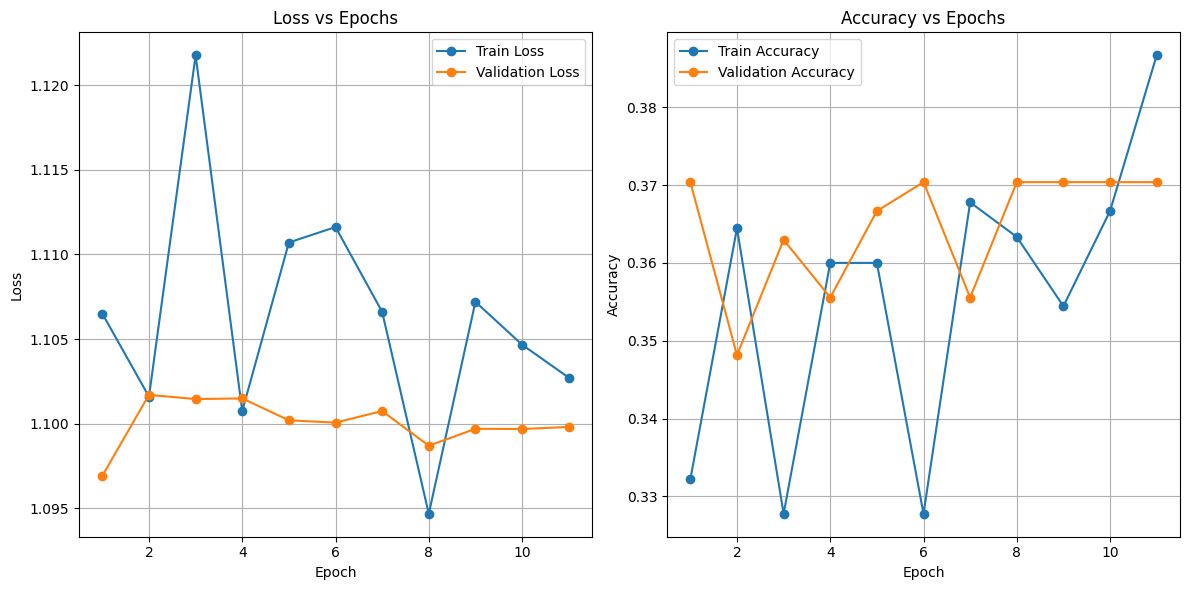

In [7]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# 1) Updated TCN Model with LeakyReLU, BatchNorm, and Dropout
class TemporalConvNet(nn.Module):
    def __init__(self, input_channels=64, num_classes=3):
        super(TemporalConvNet, self).__init__()
        
        # Convolutional layers with pooling to reduce the temporal dimension
        self.conv1 = nn.Conv1d(input_channels, 128, kernel_size=5, padding=2)
        self.batchnorm1 = nn.BatchNorm1d(128)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.batchnorm2 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm4 = nn.BatchNorm1d(256)
        self.pool4 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv5 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm5 = nn.BatchNorm1d(256)
        self.pool5 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Fully connected layers (MLP)
        self.fc1 = nn.Linear(256, 128)
        self.batchnorm_fc1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 32)
        self.batchnorm_fc2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, num_classes)
        
        self.dropout = nn.Dropout(0.7)  # Added dropout layer
    
    def forward(self, x):
        # x shape: (batch_size, 64, time_length)
        x = F.leaky_relu(self.batchnorm1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.leaky_relu(self.batchnorm2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.leaky_relu(self.batchnorm3(self.conv3(x)))
        x = self.pool3(x)
        
        x = F.leaky_relu(self.batchnorm4(self.conv4(x)))
        x = self.pool4(x)
        
        x = F.leaky_relu(self.batchnorm5(self.conv5(x)))
        x = self.pool5(x)
        
        # Global average pooling over the time dimension
        x = torch.mean(x, dim=2)
        
        x = F.leaky_relu(self.batchnorm_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = F.leaky_relu(self.batchnorm_fc2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return F.softmax(x, dim=1)

# 2) PyTorch Dataset for EEG using .vmrk files for marker extraction
class EEGBlock1Dataset(Dataset):
    """
    Loads multiple '*_filtered_down.npy' files from a directory.
    For each file, the matching '.vmrk' file is parsed from vmrk_dir by replacing
    '_filtered_down.npy' with '.vmrk'. The .vmrk file is expected to contain lines
    with stimulus codes in the format: "MkX=Stimulus,Code,...".
    
    Marker mapping:
      S11, S110 -> 0 (Left)
      S12, S120 -> 1 (Right)
      S13       -> 2 (NoShock)
    
    The first three occurrences for each stimulus marker are removed.
    If there's a mismatch in the number of epochs vs. markers after filtering,
    the data is truncated.
    """
    def __init__(self, data_dir, file_list, vmrk_dir):
        super(EEGBlock1Dataset, self).__init__()
        self.X_all = []
        self.y_all = []
        self.code_to_label = {'S11': 0, 'S110': 0, 'S12': 1, 'S120': 1, 'S13': 2}
        
        for fname in file_list:
            # 1) Load the .npy EEG data
            npy_path = os.path.join(data_dir, fname)
            if not os.path.exists(npy_path):
                print(f"Warning: {fname} not found in {data_dir}, skipping.")
                continue
            data_3d = np.load(npy_path)  # shape: (n_epochs, n_channels, n_times)
            n_epochs = data_3d.shape[0]
            
            # 2) Construct .vmrk path
            base_name = fname.replace("_filtered_down.npy", "")
            vmrk_path = os.path.join(vmrk_dir, base_name + ".vmrk")
            if not os.path.exists(vmrk_path):
                print(f"Warning: No .vmrk file found for {fname} at {vmrk_path}, skipping.")
                continue
            
            # 3) Parse the .vmrk file for stimulus codes using the filtered method
            marker_codes = self.parse_vmrk(vmrk_path)
            # 4) Remove the first three occurrences per individual stimulus marker
            filtered_marker_codes = self.filter_marker_codes(marker_codes)
            
            # 5) Truncate if mismatch (if after filtering we still have a mismatch)
            if len(filtered_marker_codes) != n_epochs:
                min_len = min(n_epochs, len(filtered_marker_codes))
                print(f"Warning: Mismatch in {fname}: data has {n_epochs} epochs, but after filtering found {len(filtered_marker_codes)} markers. Truncating to {min_len}.")
                data_3d = data_3d[:min_len]
                filtered_marker_codes = filtered_marker_codes[:min_len]
            
            # 6) Convert codes to numeric labels
            numeric_labels = [self.code_to_label[c] for c in filtered_marker_codes]
            numeric_labels = np.array(numeric_labels, dtype=int)
            
            self.X_all.append(data_3d)
            self.y_all.append(numeric_labels)
        
        # Concatenate across files
        if len(self.X_all) > 0:
            self.X_all = np.concatenate(self.X_all, axis=0)  # shape: (total_epochs, n_channels, n_times)
            self.y_all = np.concatenate(self.y_all, axis=0)  # shape: (total_epochs,)
        else:
            self.X_all = np.array([])
            self.y_all = np.array([])
    
    def parse_vmrk(self, vmrk_path):
        """
        Reads the .vmrk file and extracts stimulus codes, returning only allowed codes.
        Each line starting with "Mk" and containing "Stimulus" is processed to extract
        the code (the second comma-separated value).
        """
        allowed_codes = ['S11', 'S110', 'S12', 'S120', 'S13']
        codes = []
        with open(vmrk_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line.startswith("Mk") and "Stimulus" in line:
                    parts = line.split(',')
                    if len(parts) < 2:
                        continue
                    code_str = parts[1].strip()
                    if code_str in allowed_codes:
                        codes.append(code_str)
        return codes
    
    def filter_marker_codes(self, marker_codes):
        """
        Filters the list of marker codes by removing the first three occurrences for each individual stimulus marker.
        For each allowed marker (S11, S110, S12, S120, S13), skip the first three occurrences.
        """
        counts = {code: 0 for code in ['S11', 'S110', 'S12', 'S120', 'S13']}
        filtered = []
        for code in marker_codes:
            if counts[code] < 3:
                counts[code] += 1
                continue  # Skip the first three occurrences for this specific code
            else:
                counts[code] += 1
                filtered.append(code)
        return filtered
    
    def __len__(self):
        return self.X_all.shape[0]
    
    def __getitem__(self, idx):
        x_epoch = self.X_all[idx]  # shape: (n_channels, n_times)
        y_label = self.y_all[idx]
        return torch.from_numpy(x_epoch).float(), torch.tensor(y_label, dtype=torch.long)

# 3) Training & Validation Helper Function
def run_epoch(model, dataloader, criterion, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch_x, batch_y in dataloader:
        if optimizer:
            optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        if optimizer:
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch_y).sum().item()
        total += len(batch_y)
    avg_loss = total_loss / len(dataloader)
    avg_acc = correct / total
    return avg_loss, avg_acc

# 4) Main Script
if __name__ == "__main__":
    train_dir = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ theta range train"
    val_dir = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ theta range validation"
    test_dir = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ theta range test"
    vmrk_dir = r"C:\Users\Asus\Documents\Professor Francesca Starita\.vmrk files"
    
    train_files = [
        "01_ln_block1_filtered_down.npy",
        "02gd_block1_filtered_down.npy",
        "03as_block1_filtered_down.npy",
        "04ep_block1_filtered_down.npy",
        "06nc_block1_filtered_down.npy",
        "07fs_block1_filtered_down.npy",
        "08am_block1_filtered_down.npy",
        "09dm_block1_filtered_down.npy",
        "10lc_block1_filtered_down.npy",
        "11gb_block1_filtered_down.npy",
        "12ag_block1_filtered_down.npy",
        "13gc_block1_filtered_down.npy",
        "14es_block1_filtered_down.npy",
        "15kf_block1_filtered_down.npy",
        "16gd_block1_filtered_down.npy",
        "17st_block1_filtered_down.npy",
        "18gf_block1_filtered_down.npy",
        "19tm_block1_filtered_down.npy",
        "20md_block1_filtered_down.npy",
        "21es_block1_filtered_down.npy"
    ]
    val_files = [
        "22mc_block1_filtered_down.npy",
        "23lp_block1_filtered_down.npy",
        "24cs_block1_filtered_down.npy",
        "25vt_block1_filtered_down.npy",
        "26fs_block1_filtered_down.npy",
        "27rv_block1_filtered_down.npy"
    ]
    test_files = [
        "28gv_block1_filtered_down.npy",
        "29bc_block1_filtered_down.npy",
        "30ss_block1_filtered_down.npy"
    ]
    
    train_dataset = EEGBlock1Dataset(train_dir, train_files, vmrk_dir)
    val_dataset = EEGBlock1Dataset(val_dir, val_files, vmrk_dir)
    test_dataset = EEGBlock1Dataset(test_dir, test_files, vmrk_dir)
    
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Val dataset size:   {len(val_dataset)}")
    print(f"Test dataset size:  {len(test_dataset)}")
    
    train_loader = DataLoader(train_dataset, batch_size=22, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=22, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=22, shuffle=False)
    
    example_x, example_y = next(iter(train_loader))
    print("Example batch shape:", example_x.shape, example_y.shape)
    
    n_channels = example_x.shape[1]
    num_classes = 3
    
    model = TemporalConvNet(input_channels=n_channels, num_classes=num_classes)
    print(model)
    
    criterion = nn.CrossEntropyLoss()
    # Increased weight decay to 1e-3
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
    # Learning Rate Scheduler: Reduce LR on Plateau with factor 0.5 and patience 3
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
    
    n_epochs = 50  
    patience = 10  
    best_val_loss = float('inf')
    best_epoch = 0
    early_stop_counter = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(n_epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}")
        
        # Step the scheduler based on validation loss
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            early_stop_counter = 0
            best_model_state = model.state_dict()
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}. Best epoch: {best_epoch} with Val Loss: {best_val_loss:.4f}")
                break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}")
    
    torch.save(model.state_dict(), "tcn_block1_model.pt")
    print("Model saved as tcn_block1_model.pt")
    
    epochs_range = list(range(1, len(train_losses) + 1))
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, 'o-', label='Train Loss')
    plt.plot(epochs_range, val_losses, 'o-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs Epochs')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accuracies, 'o-', label='Train Accuracy')
    plt.plot(epochs_range, val_accuracies, 'o-', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epochs')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
